Step 0 - Explanation

In [1]:
"""
Transformer Model: Masked Nucleotide Prediction
------------------------------------------------
Dataset: Salmonella Typhimurium (6 genomes + complements)

Input files:
- train_m.txt : 10 genomes, mixed masked sequences (inputs)
- train.txt   : 10 genomes, raw sequences (targets)
- test_m.txt  : Salmonella 6, mixed masked sequences (inputs)
- test.txt    : Salmonella 6, raw sequences (targets)

Masking Strategy (from FASTA_Preprocess.ipynb):
- Position cycle (backwards): 5,4,3,2,1,5,4,3,2,1...
- Type cycle (alternating by probability)  : M,M,M,R,M,M... (e.g.)
- M = masked position, R = replaced with wrong nucleotide
- Seed 42 for reproducibility

Model Architecture:
- Custom Transformer Encoder
- Embedding dim : 128
- Attention heads: 4
- Encoder layers: 3
- Window size   : 128 (5-mers)
- Vocabulary    : 1027 (1024 5-mers + MASK + PAD + UNK)

Training:
- Optimiser : AdamW
- Loss      : Cross Entropy (masked positions only)
- Device    : CUDA if available, else CPU
"""

'\nTransformer Model: Masked Nucleotide Prediction\n------------------------------------------------\nDataset: Salmonella Typhimurium (6 genomes + complements)\n\nInput files:\n- train_m.txt : 10 genomes, mixed masked sequences (inputs)\n- train.txt   : 10 genomes, raw sequences (targets)\n- test_m.txt  : Salmonella 6, mixed masked sequences (inputs)\n- test.txt    : Salmonella 6, raw sequences (targets)\n\nMasking Strategy (from FASTA_Preprocess.ipynb):\n- Position cycle (backwards): 5,4,3,2,1,5,4,3,2,1...\n- Type cycle (alternating by probability)  : M,M,M,R,M,M... (e.g.)\n- M = masked position, R = replaced with wrong nucleotide\n- Seed 42 for reproducibility\n\nModel Architecture:\n- Custom Transformer Encoder\n- Embedding dim : 128\n- Attention heads: 4\n- Encoder layers: 3\n- Window size   : 128 (5-mers)\n- Vocabulary    : 1027 (1024 5-mers + MASK + PAD + UNK)\n\nTraining:\n- Optimiser : AdamW\n- Loss      : Cross Entropy (masked positions only)\n- Device    : CUDA if available, 

Step 1 - Imports

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import itertools
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


# ── Reproducibility seeds ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"  Seed set to {SEED}")

  Seed set to 42


Step 2 - Hyperparameters and Configuration

In [3]:
bases   = ['A', 'C', 'G', 'T']
kmers   = [''.join(k) for k in itertools.product(bases, repeat=5)]  # 1024 5-mers
kmer2idx = {kmer: idx for idx, kmer in enumerate(kmers)}             # ATGCA -> 0 etc

# Special tokens
kmer2idx['MASK'] = 1024   # masked 5-mer token
kmer2idx['PAD']  = 1025   # padding token
kmer2idx['UNK']  = 1026   # unknown 5-mer (contains N)

VOCAB      = kmer2idx
VOCAB_SIZE = len(VOCAB)   # 1027

# ── Windowing ─────────────────────────────────────────────────────────────────
WINDOW_SIZE   = 128    # now means 128 5-mers = 640 bases of context
STRIDE        = 64

# ── Model Architecture ────────────────────────────────────────────────────────
EMBED_DIM     = 128
NUM_HEADS     = 4
NUM_LAYERS    = 3
FF_DIM        = 256
DROPOUT       = 0.1

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 64
EPOCHS        = 20
LEARNING_RATE = 3e-4

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Vocabulary size : {VOCAB_SIZE}")
print(f"  Using device    : {DEVICE}")

  Vocabulary size : 1027
  Using device    : cuda


Step 3 - Dataset and Windowing

In [4]:
class DNADataset(Dataset):
    def __init__(self, masked_path, original_path, window_size=WINDOW_SIZE, stride=STRIDE):
        self.windows_input  = []
        self.windows_target = []

        masked_seqs   = open(masked_path,   "r").readlines()
        original_seqs = open(original_path, "r").readlines()

        for masked_seq, original_seq in zip(masked_seqs, original_seqs):
            masked_seq   = masked_seq.strip().upper()
            original_seq = original_seq.strip().upper()

            masked_kmers = []
            for i in range(0, len(masked_seq) - 4, 1):
                kmer = masked_seq[i:i+5]
                if "M" in kmer:
                    masked_kmers.append(VOCAB["MASK"])
                elif masked_seq[i] != original_seq[i]:
                    # replaced position (R) — window itself may still be clean of M/N (this one prevents leakage)
                    if "N" in kmer:
                        masked_kmers.append(VOCAB["UNK"])
                    else:
                        masked_kmers.append(VOCAB.get(kmer, VOCAB["UNK"]))
                else:
                    if "N" in kmer:
                        masked_kmers.append(VOCAB["UNK"])
                    else:
                        masked_kmers.append(VOCAB.get(kmer, VOCAB["UNK"]))

            original_kmers = []
            for i in range(0, len(original_seq) - 4, 1):
                kmer = original_seq[i:i+5]
                if "N" in kmer:
                    original_kmers.append(VOCAB["UNK"])
                else:
                    original_kmers.append(VOCAB.get(kmer, VOCAB["UNK"]))

            for start in range(0, len(original_kmers) - window_size, stride):
                inp = masked_kmers  [start : start + window_size]
                tgt = original_kmers[start : start + window_size]
                self.windows_input.append(torch.tensor(inp, dtype=torch.long))
                self.windows_target.append(torch.tensor(tgt, dtype=torch.long))

    def __len__(self):
        return len(self.windows_input)

    def __getitem__(self, idx):
        return self.windows_input[idx], self.windows_target[idx]


# ── Load full training set then split 85/15 into train/val ───────────────────
full_train   = DNADataset("train_mr.txt", "train.txt")
test_dataset = DNADataset("test_mr.txt",  "test.txt")

train_size = int(0.85 * len(full_train))
val_size   = len(full_train) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"  Total train windows  : {len(full_train):,}")
print(f"  Train split (85%)    : {len(train_dataset):,}")
print(f"  Val split   (15%)    : {len(val_dataset):,}")
print(f"  Test windows         : {len(test_dataset):,}")


  Total train windows  : 775,244
  Train split (85%)    : 658,957
  Val split   (15%)    : 116,287
  Test windows         : 77,075


In [5]:
with open("train.txt") as f:
    seq = f.read().replace("\n", "")

counts = Counter(seq)
total = len(seq)
for base, count in sorted(counts.items()):
    print(f"  {base}: {count:,} ({count/total*100:.1f}%)")

  A: 11,881,112 (23.9%)
  C: 12,919,822 (26.0%)
  G: 12,933,215 (26.1%)
  T: 11,881,557 (23.9%)


Step 4 - Transformer Model

In [6]:
class DNATransformer(nn.Module):
    def __init__(self):
        super(DNATransformer, self).__init__()

        # Embedding layer: converts 5-mer token IDs to vectors
        # 1027 possible tokens (1024 5-mers + MASK + PAD + UNK)
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=VOCAB['PAD'])

        # Positional encoding: tells the model where each 5-mer is in the window
        self.pos_embedding = nn.Embedding(WINDOW_SIZE, EMBED_DIM)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = EMBED_DIM,
            nhead           = NUM_HEADS,
            dim_feedforward = FF_DIM,
            dropout         = DROPOUT,
            batch_first     = True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)

        # Output layer: predicts one of VOCAB_SIZE 5-mer tokens at each position
        self.output_layer = nn.Linear(EMBED_DIM, VOCAB_SIZE)

    def forward(self, x):
        # x shape: (batch, window_size)

        # Create position indices [0, 1, 2, ..., window_size-1]
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)

        # 5-mer token embeddings + positional embeddings
        x = self.embedding(x) + self.pos_embedding(positions)

        # Pass through transformer encoder
        x = self.transformer(x)

        # Project to vocabulary size (1027)
        x = self.output_layer(x)

        return x  # shape: (batch, window_size, vocab_size)


# ── Initialise model ──────────────────────────────────────────────────────────
model = DNATransformer().to(DEVICE)
print(model)
print(f"\n  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

DNATransformer(
  (embedding): Embedding(1027, 128, padding_idx=1025)
  (pos_embedding): Embedding(128, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=128, out_features=1027, bias=True)
)

  Total parameters: 677,763


Step 5 - Training Loop

In [7]:
PATIENCE         = 2
best_loss        = float("inf")
patience_counter = 0

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0; total_correct = 0; total_masked = 0
    for input_kmers, target_kmers in loader:
        input_kmers  = input_kmers.to(DEVICE)
        target_kmers = target_kmers.to(DEVICE)
        optimizer.zero_grad()
        output         = model(input_kmers)
        mask           = (input_kmers == VOCAB["MASK"]) | (input_kmers != target_kmers)
        masked_output  = output[mask]
        masked_targets = target_kmers[mask]
        loss           = criterion(masked_output, masked_targets)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item()
        predictions    = masked_output.argmax(dim=-1)
        total_correct += (predictions == masked_targets).sum().item()
        total_masked  += mask.sum().item()
    return total_loss / len(loader), total_correct / total_masked * 100


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0; total_correct = 0; total_masked = 0
    with torch.no_grad():
        for input_kmers, target_kmers in loader:
            input_kmers  = input_kmers.to(DEVICE)
            target_kmers = target_kmers.to(DEVICE)
            output         = model(input_kmers)
            mask           = (input_kmers == VOCAB["MASK"]) | (input_kmers != target_kmers)
            masked_output  = output[mask]
            masked_targets = target_kmers[mask]
            loss           = criterion(masked_output, masked_targets)
            total_loss    += loss.item()
            predictions    = masked_output.argmax(dim=-1)
            total_correct += (predictions == masked_targets).sum().item()
            total_masked  += mask.sum().item()
    return total_loss / len(loader), total_correct / total_masked * 100


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion)
    print(f"  Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    scheduler.step(val_loss)
    if val_loss < best_loss:
        best_loss        = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "transformer_best_5mer_mr.pth")
        print(f"  --> Best model saved at epoch {epoch}")
    else:
        patience_counter += 1
        print(f"  --> No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}!")
            break

  Epoch 01/20 | Train Loss: 6.3038 | Train Acc: 1.96% | Val Loss: 3.9910 | Val Acc: 10.44%
  --> Best model saved at epoch 1
  Epoch 02/20 | Train Loss: 2.1620 | Train Acc: 25.79% | Val Loss: 1.6203 | Val Acc: 33.20%
  --> Best model saved at epoch 2
  Epoch 03/20 | Train Loss: 1.6923 | Train Acc: 31.46% | Val Loss: 1.5927 | Val Acc: 34.19%
  --> Best model saved at epoch 3
  Epoch 04/20 | Train Loss: 1.6443 | Train Acc: 32.86% | Val Loss: 1.5836 | Val Acc: 34.69%
  --> Best model saved at epoch 4
  Epoch 05/20 | Train Loss: 1.6224 | Train Acc: 33.73% | Val Loss: 1.5732 | Val Acc: 35.42%
  --> Best model saved at epoch 5
  Epoch 06/20 | Train Loss: 1.6038 | Train Acc: 34.63% | Val Loss: 1.5600 | Val Acc: 36.12%
  --> Best model saved at epoch 6
  Epoch 07/20 | Train Loss: 1.5880 | Train Acc: 35.34% | Val Loss: 1.5443 | Val Acc: 36.68%
  --> Best model saved at epoch 7
  Epoch 08/20 | Train Loss: 1.5750 | Train Acc: 35.83% | Val Loss: 1.5373 | Val Acc: 37.01%
  --> Best model saved at e

  EVALUATION RESULTS — Salmonella (Unseen Genome)
  Test Loss                        : 1.4971
  Test Accuracy (5-mer token)       : 38.90%
  Test Accuracy (single nucleotide) : 85.42%
  Total active positions            : 8,287,104
Classification Report (per nucleotide):
              precision    recall  f1-score   support

           A     0.8726    0.8328    0.8522   1983909
           T     0.8510    0.8443    0.8477   1982120
           G     0.8503    0.8658    0.8580   2158096
           C     0.8452    0.8713    0.8580   2162979

    accuracy                         0.8542   8287104
   macro avg     0.8548    0.8535    0.8540   8287104
weighted avg     0.8545    0.8542    0.8541   8287104



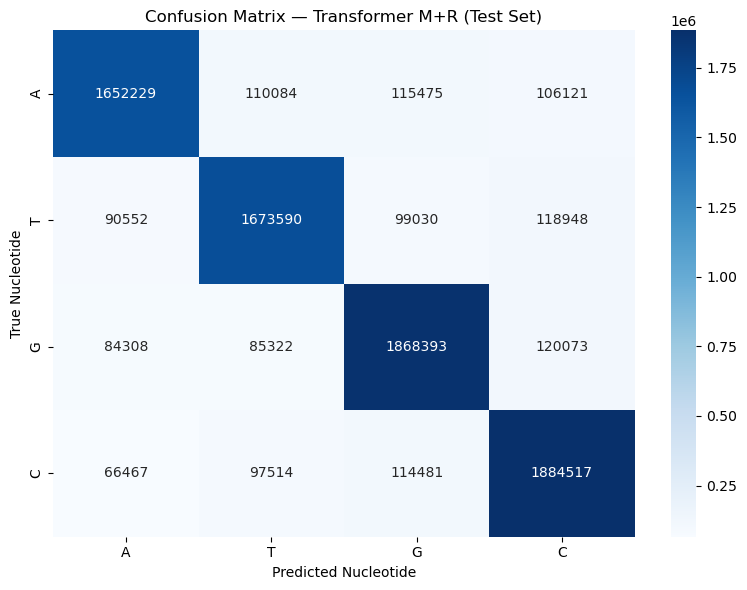

  Confusion matrix saved as confusion_matrix_transformer_mr.png


In [11]:
# Load best model
model.load_state_dict(torch.load("transformer_best_5mer_mr.pth", map_location=DEVICE))
model.eval()

all_preds   = []
all_targets = []
total_correct = 0
total_masked  = 0
total_loss    = 0

idx2kmer = {v: k for k, v in VOCAB.items() if len(k) == 5}
def kmer_to_nuc(idx):
    kmer = idx2kmer.get(idx, "N")
    return kmer[0] if kmer != "N" else "N"

with torch.no_grad():
    for input_kmers, target_kmers in test_loader:
        input_kmers  = input_kmers.to(DEVICE)
        target_kmers = target_kmers.to(DEVICE)
        output         = model(input_kmers)
        mask           = (input_kmers == VOCAB["MASK"]) | (input_kmers != target_kmers)
        masked_output  = output[mask]
        masked_targets = target_kmers[mask]
        loss           = criterion(masked_output, masked_targets)
        total_loss    += loss.item()
        predictions    = masked_output.argmax(dim=-1)
        total_correct += (predictions == masked_targets).sum().item()   # 5-mer match
        total_masked  += mask.sum().item()
        all_preds.extend  ([kmer_to_nuc(p.item()) for p in predictions])
        all_targets.extend([kmer_to_nuc(t.item()) for t in masked_targets])

# ── 5-mer token accuracy (strict: full 5-mer index must match) ────────────────
test_accuracy_5mer = total_correct / total_masked * 100
test_loss           = total_loss / len(test_loader)

# ── Nucleotide-level accuracy (first base of predicted vs true token) ─────────
nucleotide_correct  = sum(1 for p, t in zip(all_preds, all_targets) if p == t)
nucleotide_total    = len(all_targets)
test_accuracy_nuc   = nucleotide_correct / nucleotide_total * 100

print("=" * 60)
print("  EVALUATION RESULTS — Salmonella (Unseen Genome)")
print("=" * 60)
print(f"  Test Loss                        : {test_loss:.4f}")
print(f"  Test Accuracy (5-mer token)       : {test_accuracy_5mer:.2f}%")
print(f"  Test Accuracy (single nucleotide) : {test_accuracy_nuc:.2f}%")
print(f"  Total active positions            : {total_masked:,}")
print("=" * 60)

print("Classification Report (per nucleotide):")
print(classification_report(all_targets, all_preds, labels=["A", "T", "G", "C"], digits=4))

labels = ["A", "T", "G", "C"]
cm = confusion_matrix(all_targets, all_preds, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels
)
plt.title("Confusion Matrix — Transformer M+R (Test Set)")
plt.xlabel("Predicted Nucleotide")
plt.ylabel("True Nucleotide")
plt.tight_layout()
plt.savefig("confusion_matrix_transformer_mr.png", dpi=150)
plt.show()
print("  Confusion matrix saved as confusion_matrix_transformer_mr.png")

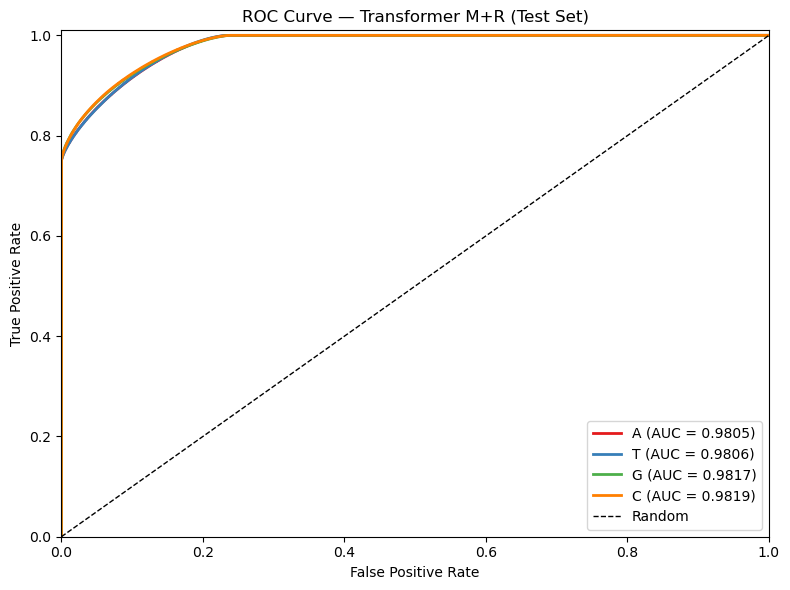

  ROC curve saved as roc_curve_transformer_mr.png


In [12]:

model.eval()
all_probs  = []
all_true   = []
nuc_labels = ['A', 'T', 'G', 'C']
nuc_to_idx = {'A': 0, 'T': 1, 'G': 2, 'C': 3}

with torch.no_grad():
    for input_kmers, target_kmers in test_loader:
        input_kmers  = input_kmers.to(DEVICE)
        target_kmers = target_kmers.to(DEVICE)
        output       = model(input_kmers)
        mask = (input_kmers == VOCAB['MASK']) | (input_kmers != target_kmers)
        masked_output  = output[mask]
        masked_targets = target_kmers[mask]

        probs = torch.softmax(masked_output, dim=-1).cpu().numpy()
        tgts  = masked_targets.cpu().numpy()

        nuc_probs = np.zeros((probs.shape[0], 4))
        for nuc_i, nuc in enumerate(nuc_labels):
            kmer_indices = [v for k, v in VOCAB.items() if len(k) == 5 and k[0] == nuc]
            nuc_probs[:, nuc_i] = probs[:, kmer_indices].sum(axis=1)

        true_nucs = [kmer_to_nuc(p) for p in tgts]
        true_idxs = [nuc_to_idx.get(n, 0) for n in true_nucs]

        all_probs.extend(nuc_probs.tolist())
        all_true.extend(true_idxs)

all_probs    = np.array(all_probs)
all_true     = np.array(all_true)
all_true_bin = label_binarize(all_true, classes=[0, 1, 2, 3])

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']
plt.figure(figsize=(8, 6))

for i, (nuc, color) in enumerate(zip(nuc_labels, colors)):
    fpr, tpr, _ = roc_curve(all_true_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{nuc} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Transformer M+R (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_transformer_mr.png', dpi=150)
plt.show()
print('  ROC curve saved as roc_curve_transformer_mr.png')